In [1]:
import numpy as np
import matplotlib.pyplot as plt

# El oscilador armónico

La ecuación del oscilador armónico
$$
\ddot x + \omega _0 ^2 x = 0
$$

hacemos $\tau= \omega _0 t$ y entonces $\frac{d}{dt} =  \frac{d \tau}{dt}\frac{d}{d\tau} = \omega _0 \frac{d}{d\tau}$ y $\frac{d^2}{d t^2}= \omega _0 ^2 \frac{d^2}{d\tau^2}$. Lo cual quiere decir que:

$$
x'' + x = 0
$$

donde la prima denota la derivada respecto $\tau$. Hacemos $x' = v_x$ y por lo tanto

$$
x' = v_x\\
v_x ' = -x
$$

donde las variables $x$ y $v_x$. En este caso $\mathbb{J}$ es

$$
\mathbb{J} = \left(
\begin{matrix}
0 & 1 \\
-1 & 0
\end{matrix} \right)
$$

Vamos a encontrar la solucion a la EDO anterior con la condición inicial $x(0) = 1$ y $x'(0)=v_x(0)=0$

In [22]:
def Euler(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
    return sol

In [23]:
def osc(x_vx,t):
    return np.array( [ x_vx[1] , -x_vx[0] ] )

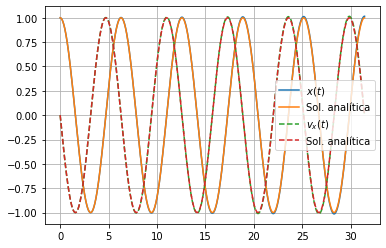

In [38]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.001)
sol = Euler(osc,x_ini,t)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'--',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()

In [26]:
def RK2(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        t_med = t[i] + 0.5*h
        sol_med = sol[:,i] + 0.5*h*g(sol[:,i],t[i])
        sol[:,i+1] = sol[:,i] + h*g(sol_med,t_med)
    return sol

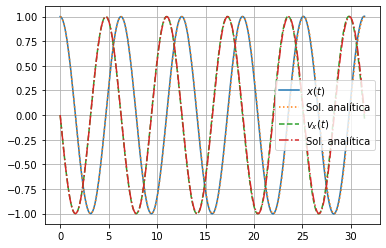

In [51]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)
sol = RK2(osc,x_ini,t)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),':',label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'-.',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()

In [42]:
a , b = np.array([[1,2],[3,4]]) , np.array([3,6])
a , b , a*b , np.dot(a,b)

(array([[1, 2],
        [3, 4]]),
 array([3, 6]),
 array([[ 3, 12],
        [ 9, 24]]),
 array([15, 33]))

In [46]:
def Euler_mejorado(g,x0,t,Jac):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
        sol[:,i+1] += 0.5*np.dot(Jac(sol[:,i],t[i]),g(sol[:,i],t[i]))*h**2
    return sol

In [47]:
def J_osc(x_vx,t):
    return np.array([[0,1],[-1,0]])

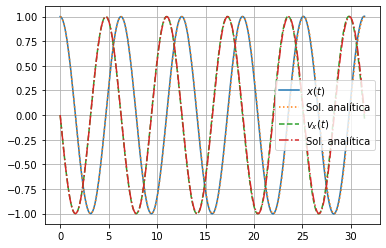

In [52]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)
sol = Euler_mejorado(osc,x_ini,t,J_osc)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),':',label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'-.',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()